In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration to display graphs in the notebook
%matplotlib inline
plt.style.use('ggplot')
sns.set(style='whitegrid')


# <b><span style='color:#F1A424'>|</span> Data Loading and Initial Exploration <span style='color:#F1A424'>|</span></b>
Load your dataset and get a first look at its structure and contents.


In [2]:
# Load the dataset
df = pd.read_csv('Datasets/Tabular/Time_series/csv/dataset_time_series.csv')

# Display basic information
print("Table shape:", df.shape)
print("Column names:", df.columns.tolist())
df.head()


Table shape: (9990, 13)
Column names: ['Unnamed: 0', 'ID', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Target']


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


# <b><span style='color:#F1A424'>|</span> Categorical Data Encoding <span style='color:#F1A424'>|</span></b>
Convert categorical variables into numeric codes for analysis.


In [3]:
# Transform categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print("\nDataFrame after categorical encoding:")
df.head()



DataFrame after categorical encoding:


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


# <b><span style='color:#F1A424'>|</span> Correlation Analysis <span style='color:#F1A424'>|</span></b>
Analyze the relationships between features to inform feature selection.
We are using the absolute value of the correlation matrix to get insight on the magnitude of the correlation between the features, as the sign of the correlation is not important for the feature selection step.


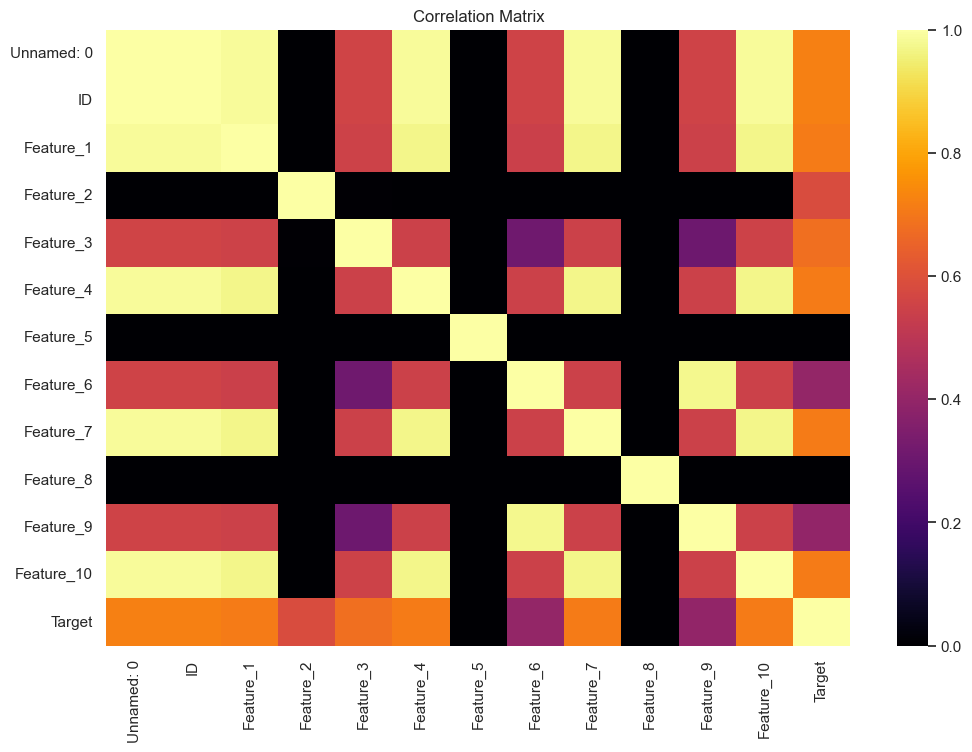

In [4]:
# Display correlation matrix
corr_matrix = df.corr().abs()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='inferno', vmin=0, vmax=1)
plt.title('Correlation Matrix')
plt.show()


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader


# <b><span style='color:#F1A424'>|</span> Data Preparation and Splitting <span style='color:#F1A424'>|</span></b>
Splitting the data into training and test sets, and normalizing the features.


In [6]:
# Split and preprocess the data
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Target']), df['Target'], test_size=0.2, random_state=42)

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# <b><span style='color:#F1A424'>|</span> Tensor Conversion <span style='color:#F1A424'>|</span></b>
Converting the data into PyTorch tensors.


In [7]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)


# <b><span style='color:#F1A424'>|</span> Neural Network Architecture <span style='color:#F1A424'>|</span></b>
Definition of the neural network architecture for regression.


In [8]:
class NeuralNetModel(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(32)
    
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x


In [9]:
# Initialize model and training components
input_size = X_train.shape[1]
model = NeuralNetModel(input_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


# <b><span style='color:#F1A424'>|</span> Training Loop <span style='color:#F1A424'>|</span></b>
Training loop with early stopping and saving the best model.


In [10]:
# Training parameters
num_epochs = 200
patience = 15
best_loss = float('inf')
counter = 0
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())
        
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_lstm_model.pth')
        else:
            counter += 1
    
    if counter >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}')

# Load best model
model.load_state_dict(torch.load('best_lstm_model.pth'))


Epoch [10/200], Train Loss: 12.1632, Val Loss: 5.1268


Epoch [20/200], Train Loss: 12.1394, Val Loss: 6.3665


Epoch [30/200], Train Loss: 9.8993, Val Loss: 4.4566


Epoch [40/200], Train Loss: 10.3450, Val Loss: 4.4874


Epoch [50/200], Train Loss: 10.6748, Val Loss: 4.3371


Early stopping triggered at epoch 60


<All keys matched successfully>

# <b><span style='color:#F1A424'>|</span> Model Evaluation <span style='color:#F1A424'>|</span></b>
Evaluating the model's performance on the test set.


In [11]:
# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'MSE: {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'R² Score: {r2:.4f}')


MSE: 4.2057
RMSE: 2.0508
MAE: 1.6077
R² Score: 0.9822


# <b><span style='color:#F1A424'>|</span> Learning Curve <span style='color:#F1A424'>|</span></b>
Visualization of the model's learning curve during training.


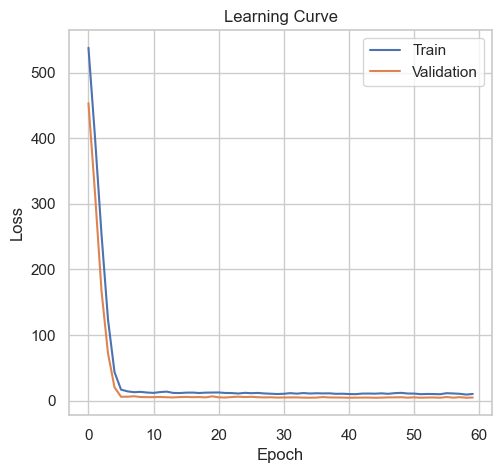

In [12]:
# Plot learning curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])


# <b><span style='color:#F1A424'>|</span> Predictions vs Actual <span style='color:#F1A424'>|</span></b>
Visualization of the model's predictions compared to the actual values.


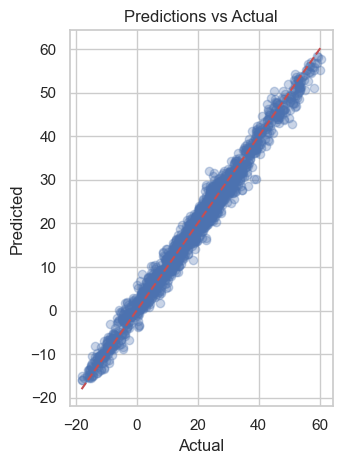

In [13]:
# Plot predictions vs actual
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()
